# Dataset class and helper functions

In [19]:
# Define constant variables

SMALL_BATCH_TEST = False # toggle on/off

FEAT_COLS = ['eeg_c4_mean', 'eeg_c4_std', 'eeg_c4_min', 'eeg_c4_max', 'eeg_c4_range', 'eeg_c4_slope', 'eeg_f4_mean', 'eeg_f4_std', 'eeg_f4_min', 'eeg_f4_max', 'eeg_f4_range', 'eeg_f4_slope', 'eeg_o2_mean', 'eeg_o2_std', 'eeg_o2_min', 'eeg_o2_max', 'eeg_o2_range', 'eeg_o2_slope', 'eeg_fp1_mean', 'eeg_fp1_std', 'eeg_fp1_min', 'eeg_fp1_max', 'eeg_fp1_range', 'eeg_fp1_slope', 'eeg_t3_mean', 'eeg_t3_std', 'eeg_t3_min', 'eeg_t3_max', 'eeg_t3_range', 'eeg_t3_slope', 'eeg_cz_mean', 'eeg_cz_std', 'eeg_cz_min', 'eeg_cz_max', 'eeg_cz_range', 'eeg_cz_slope', 'eog_e1_mean', 'eog_e1_std', 'eog_e1_min', 'eog_e1_max', 'eog_e1_range', 'eog_e1_slope', 'eog_e2_mean', 'eog_e2_std', 'eog_e2_min', 'eog_e2_max', 'eog_e2_range', 'eog_e2_slope', 'emg_chin_mean', 'emg_chin_std', 'emg_chin_min', 'emg_chin_max', 'emg_chin_range', 'emg_chin_slope', 'emg_lat_mean', 'emg_lat_std', 'emg_lat_min', 'emg_lat_max', 'emg_lat_range', 'emg_lat_slope', 'emg_rat_mean', 'emg_rat_std', 'emg_rat_min', 'emg_rat_max', 'emg_rat_range', 'emg_rat_slope', 'resp_ptaf_mean', 'resp_ptaf_std', 'resp_ptaf_min', 'resp_ptaf_max', 'resp_ptaf_range', 'resp_ptaf_slope', 'resp_flow_mean', 'resp_flow_std', 'resp_flow_min', 'resp_flow_max', 'resp_flow_range', 'resp_flow_slope', 'resp_thorax_mean', 'resp_thorax_std', 'resp_thorax_min', 'resp_thorax_max', 'resp_thorax_range', 'resp_thorax_slope', 'resp_abdomen_mean', 'resp_abdomen_std', 'resp_abdomen_min', 'resp_abdomen_max', 'resp_abdomen_range', 'resp_abdomen_slope', 'bvp_mean', 'bvp_std', 'bvp_min', 'bvp_max', 'bvp_range', 'bvp_slope', 'ibi_mean', 'ibi_std', 'ibi_min', 'ibi_max', 'ibi_range', 'ibi_slope', 'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_range', 'eda_slope', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_range', 'temp_slope', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'hr_slope', 'snore_mean', 'snore_std', 'snore_min', 'snore_max', 'snore_range', 'snore_slope', 'sao2_mean', 'sao2_std', 'sao2_min', 'sao2_max', 'sao2_range', 'sao2_slope', 'eeg_c4_bp_delta', 'eeg_c4_bp_theta', 'eeg_c4_bp_alpha', 'eeg_c4_bp_sigma', 'eeg_c4_bp_beta', 'eeg_c4_bp_gamma', 'eeg_c4_bp_high_gamma', 'eeg_f4_bp_delta', 'eeg_f4_bp_theta', 'eeg_f4_bp_alpha', 'eeg_f4_bp_sigma', 'eeg_f4_bp_beta', 'eeg_f4_bp_gamma', 'eeg_f4_bp_high_gamma', 'eeg_o2_bp_delta', 'eeg_o2_bp_theta', 'eeg_o2_bp_alpha', 'eeg_o2_bp_sigma', 'eeg_o2_bp_beta', 'eeg_o2_bp_gamma', 'eeg_o2_bp_high_gamma', 'eeg_fp1_bp_delta', 'eeg_fp1_bp_theta', 'eeg_fp1_bp_alpha', 'eeg_fp1_bp_sigma', 'eeg_fp1_bp_beta', 'eeg_fp1_bp_gamma', 'eeg_fp1_bp_high_gamma', 'eeg_t3_bp_delta', 'eeg_t3_bp_theta', 'eeg_t3_bp_alpha', 'eeg_t3_bp_sigma', 'eeg_t3_bp_beta', 'eeg_t3_bp_gamma', 'eeg_t3_bp_high_gamma', 'eeg_cz_bp_delta', 'eeg_cz_bp_theta', 'eeg_cz_bp_alpha', 'eeg_cz_bp_sigma', 'eeg_cz_bp_beta', 'eeg_cz_bp_gamma', 'eeg_cz_bp_high_gamma', 'eog_e1_bp_slow', 'eog_e1_bp_delta', 'eog_e1_bp_theta', 'eog_e1_bp_high', 'eog_e2_bp_slow', 'eog_e2_bp_delta', 'eog_e2_bp_theta', 'eog_e2_bp_high', 'emg_chin_bp_low', 'emg_chin_bp_medium', 'emg_chin_bp_high', 'emg_lat_bp_low', 'emg_lat_bp_medium', 'emg_lat_bp_high', 'emg_rat_bp_low', 'emg_rat_bp_medium', 'emg_rat_bp_high', 'ibi_sdnn', 'ibi_rmssd', 'ibi_pnn50', 'eda_scr_count', 'eda_scr_mean_amp', 'hr_bvp_corr', 'acc_eda_corr']
TARGET_COL = ['sleep_stage']
SIGNAL_DIR = '../data/processed/data_100Hz'
METADATA_CSV = '../data/processed/participant_info_preprocessed.csv'
FEAT_METADATA_COLS = ['age', 'bmi', 'mean_sao2', 'gender_m', 'med_anxiety', 'med_arrhythmia', 'med_asthma', 'med_body_pain', 'med_cad', 'med_depression', 'med_diabetes', 'med_dyspnea', 'med_gerd', 'med_hypertension', 'med_migraine', 'med_osa']

SUBJECTS = ['S'+'0'*(3-len(str(n)))+str(n) for n in range(2,104)]


In [20]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional, Sequence, Literal

import math
import random

import numpy as np
import pandas as pd

In [21]:
@dataclass
class BlockSample:
    subject_id: str
    block_id: int
    start_idx: int
    end_idx: int

In [22]:
class SleepDataset:
    """
    Each input parquet file is assumed to contain one subject's time-ordered windowed data:
      - time column
      - feature columns
      - label columns

    The dataset indexes contiguous blocks within each subject and returns:
      X_block: (n_samples, n_features)
      y_block: (n_samples,)
      meta: dict with subject/block info
    """
    def __init__(
            self,
            signals_dir: str | Path,
            metadata_csv: str | Path,
            feature_cols: Sequence[str],
            label_cols: Sequence[str],
            subject_col_meta: str = "sid",
            signals_file_pattern: str = "{subject_id}.parquet",
            block_duration_sec: float = 30.0*60.0,  # 30 minutes
            epoch_sec: Optional[float] = 5.0, # 5s epochs
            horizon: int = 0,
            allowed_subjects: Optional[Sequence[str]] = None,
            drop_boundary: int = 25//5, # assume EXTENDED_EPOCH=25s, EPOCH=5s, horizon=0
            tail_policy: str = "drop",
            preload: bool = False,
    ) -> None:
        """
        Parameters
        ----------
        signals_dir:
            Folder containing one parquet file per subject.
        metadata_csv:
            CSV with subject-level metadata.
        feature_cols:
            Names of feature columns to use from parquet.
        label_cols:
            Names of label columns in parquet (sleep stage, apnea events, etc.).
        subject_col_meta:
            Subject id column in metadata csv.
        signals_file_pattern:
            Pattern for parquet filenames, e.g. "{subject_id}.parquet".
        block_duration_sec:
            Duration of each block in seconds. 
        epoch_sec:
            Duration represented by each row/epoch.
        horizon:
            Future prediction shift. y[t] becomes label at t + horizon.
        allowed_subjects:
            List of allowed sid.
        drop_boundary:
            Number of windows to drop at both / beginning sides of each block boundary.
            Minimal version keeps this simple by shrinking each block internally.
        tail_policy:
            Decide what to do with the remainder len(df)%block_size.
            "merge": merge remainder epochs into last block
            "pad" : add remainder with padding to new block such that all blocks are same length
            "drop" : drop remainder epochs
        preload:
            If True, load all subject data at init. Otherwise lazy-load.
        """
        self.signals_dir = Path(signals_dir)
        self.metadata = pd.read_csv(metadata_csv)
        self.feature_cols = list(feature_cols)
        self.label_cols = list(label_cols)
        self.subject_col_meta = subject_col_meta
        self.signals_file_pattern = signals_file_pattern
        self.preload = preload
        
        if block_duration_sec <= epoch_sec: # type: ignore
            raise ValueError(f"block_duration_sec must be >= epoch_sec {epoch_sec}s")
        self.block_size = int(block_duration_sec//epoch_sec) # type: ignore

        if horizon < 0:
            raise ValueError("horizon must be >= 0.")            
        self.horizon = horizon
        self.drop_boundary = drop_boundary + horizon

        policies = {"merge", "drop", "pad"}
        if tail_policy not in ("merge", "drop", "pad"):
            print(f"{tail_policy} not in {policies}, fall back to drop tail.")
            tail_policy = "drop"
        self.tail_policy = tail_policy

        all_subjects = self.metadata[self.subject_col_meta].astype(str).tolist()
        if all_subjects is None:
            raise KeyError(f"No subjects found from {metadata_csv}.")
        else:
            allowed_set = set(map(str, allowed_subjects)) # pyright: ignore[reportArgumentType]
            all_subjects = [sid for sid in all_subjects if sid in allowed_set]
        self.subject_ids = all_subjects

        # drop certain columns in metadata
        self.meta_by_subject = (
            self.metadata.assign(**{self.subject_col_meta: self.metadata[self.subject_col_meta].astype(str)})
            .set_index(self.subject_col_meta)
            .to_dict(orient="index")
        )

        # cache for loaded df
        self._cache: dict[str, pd.DataFrame] = {}

        if self.preload:
            for sid in self.subject_ids:
                self._cache[sid] = self._load_subject_df(sid)
        
        # build block index
        self.all_blocks: list[BlockSample] = self._build_index()
        
    # -- subject loading --
    def _subject_path(self, subject_id: str) -> Path:
        return self.signals_dir / self.signals_file_pattern.format(subject_id=subject_id)
    
    def _load_subject_df(self, subject_id: str) -> pd.DataFrame:
        path = self._subject_path(subject_id)
        if not path.exists():
            raise FileNotFoundError(f"Missing parquet for subject {subject_id}: {path}")
        df = pd.read_parquet(path).copy()

        # check columns
        required = set(self.feature_cols + self.label_cols)
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{path} file missing columns: {sorted(missing)}")
        
        # assuming rows are already sorted as time ordered. 
        return df
    
    # -- block indexing --
    def _get_subject_df(self, subject_id: str) -> pd.DataFrame:
        if subject_id not in self._cache:
            self._cache[subject_id] = self._load_subject_df(subject_id)
        return self._cache[subject_id]
    
    def _build_index(self) -> list[BlockSample]:
        all_blocks: list[BlockSample] = []
        needed_block_len = 2 * self.drop_boundary
        if self.block_size < needed_block_len:
            raise ValueError(
                f"block_size={self.block_size} is too small for drop_boundary={needed_block_len}"
            )
        # TODO: implement different tail strategies. Everything leads to "drop" tail for now.
        for sid in self.subject_ids:
            df = self._get_subject_df(sid)
            n = len(df)
            n_blocks = n // self.block_size
            mod_blocks = n % self.block_size
            for b in range(n_blocks):
                start = b * self.block_size
                end = start + self.block_size
                all_blocks.append(
                    BlockSample(
                        subject_id=sid,
                        block_id=b,
                        start_idx=start,
                        end_idx=end,
                    )
                )
        return all_blocks
    
    # -- purge boundaries --
    def __len__(self) -> int:
        return len(self.all_blocks)
    def __getitem__(self, idx: int):
        """get X, y, meta from single block"""
        block = self.all_blocks[idx]
        df = self._get_subject_df(block.subject_id)
        block_df = df.iloc[block.start_idx : block.end_idx].reset_index(drop=True)

        # purge boundaies
        if self.drop_boundary > 0:
            block_df = block_df.iloc[self.drop_boundary : len(block_df)].reset_index(drop=True)
        X = block_df[self.feature_cols].to_numpy(dtype=np.float32)
        y = block_df[self.label_cols].to_numpy()

        # apply horizon shift
        if self.horizon > 0:
            if len(block_df) <= self.horizon:
                raise ValueError(f"Block sid={block.subject_id}, block_id={block.block_id} is too short for horizon={self.horizon}.")
            X = X[:-self.horizon]
            y = y[self.horizon:]
        
        # apply meta data
        subject_meta = self.meta_by_subject.get(block.subject_id, {})
        # TODO: customize meata features to include
        meta_feature_cols = FEAT_METADATA_COLS
        meta_values = np.array(
            [subject_meta.get(col, np.nan) for col in meta_feature_cols],
            dtype=np.float32,
        )
        meta_matrix = np.tile(meta_values, (X.shape[0],1))
        X = np.hstack([X,meta_matrix])

        meta = {
            "subject_id": block.subject_id,
            "block_id" : block.block_id,
            "start_idx" : block.start_idx,
            "end_idx" : block.end_idx,
            "n_rows_raw": block.end_idx - block.start_idx,
            "n_rows_final": len(y),
            "subject_meta": self.meta_by_subject.get(block.subject_id, {}),
        }

        return X, y, meta

In [23]:
# --- Helper Functions ---

# -- leave n subject out --
from collections import defaultdict


def make_leave_n_out_split(
        subject_ids: Sequence[str],
        n_test: int,
        seed: int = 42,
) -> tuple[list[str], list[str]]:
    subject_ids = list(map(str,subject_ids))
    if not (1 <= n_test < len(subject_ids)):
        raise ValueError("n_test must be between 1 and len(subject_ids)-1.")
    rng = random.Random(seed)
    shuffled = subject_ids[:]
    rng.shuffle(shuffled)
    test_subjects = shuffled[:n_test]
    train_subjects = shuffled[n_test:]
    return train_subjects, test_subjects

# -- split blocks into train,val,test within subject --
def split_within_subject(
        dataset: SleepDataset,
        ratio: Sequence[float]=(0.6,0.2,0.2),
        seed: int = 42,
) -> list[int]:
    
    # Group dataset
    subject_blocks = defaultdict(list)
    for idx, block in enumerate(dataset.all_blocks):
        subject_blocks[block.subject_id].append(idx)
    
    train_ids = []
    val_ids = []
    test_ids = []

    # shuffle and collect block indices
    for subject_id, indices in subject_blocks.items():
        # sort indices by block_id
        indices = sorted(indices, key=lambda i: dataset.all_blocks[i].block_id)
        subject_seed = seed + int(subject_id[1:])*2
        rng = random.Random(subject_seed)
        indices = indices[:]
        rng.shuffle(indices)

        # split indices
        n = len(indices)
        if n < 3:
            print(f"Subject {subject_id} has only {n} blocks, skip train-val-test split.")
            return None

        n_train = round(n*ratio[0])
        n_val = round(n*ratio[1])
        n_test = n-n_train-n_val

        if min(n_train, n_val, n_test) == 0:
            print(
                f"Subject {subject_id} has too few blocks ({n}) for ratios={ratio}. "
                f"Got split sizes train={n_train}, val={n_val}, test={n_test}."
            )

        train_ids.extend(indices[:n_train])
        val_ids.extend(indices[n_train:n_train+n_val])
        test_ids.extend(indices[n_train + n_val:])

    return train_ids, val_ids, test_ids # pyright: ignore[reportReturnType]
    
    

# -- make subset --
class DatasetSubset:
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        return self.dataset[self.indices[i]]

# -- flatten dataset --
def flatten_dataset(dataset: SleepDataset | DatasetSubset):
    X_list = []
    y_list = []
    rows = []

    for i in range(len(dataset)):
        X_block, y_block, meta = dataset[i]
        X_list.append(X_block)
        y_list.append(y_block)
        
        # multiply metat data by rows of block
        rows.extend(
            {
                "subject_id": meta["subject_id"],
                "block_id": meta["block_id"],
                "row_in_block": row_idx,
            }
            for row_idx in range(len(y_block))  
        )
    X = np.vstack(X_list)
    y = np.vstack(y_list)
    info = pd.DataFrame(rows)
    return X, y, info

# -- encode sleep_stage col --
STAGE_MAP = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "R": 4,
}
def encode_labels(X, y, stage_map=STAGE_MAP):
    # TODO: (optional) apply to info too, or remove info from previous functions
    y = np.asarray(y).flatten()
    mask = np.isin(y, list(STAGE_MAP.keys()))
    X = X[mask]
    y = y[mask]
    y = np.array([stage_map[s] for s in y], dtype=np.int64)
    return X, y

# Check variables and load dataset

In [ ]:
# # define columns
# df = pd.read_parquet("../data/processed/data_100Hz/S002.parquet")
# print(list(df.columns))
# print(df[['epoch_id','sleep_stage']].head())

['epoch_id', 'epoch_start', 'epoch_end', 'eeg_c4_mean', 'eeg_c4_std', 'eeg_c4_min', 'eeg_c4_max', 'eeg_c4_range', 'eeg_c4_slope', 'eeg_f4_mean', 'eeg_f4_std', 'eeg_f4_min', 'eeg_f4_max', 'eeg_f4_range', 'eeg_f4_slope', 'eeg_o2_mean', 'eeg_o2_std', 'eeg_o2_min', 'eeg_o2_max', 'eeg_o2_range', 'eeg_o2_slope', 'eeg_fp1_mean', 'eeg_fp1_std', 'eeg_fp1_min', 'eeg_fp1_max', 'eeg_fp1_range', 'eeg_fp1_slope', 'eeg_t3_mean', 'eeg_t3_std', 'eeg_t3_min', 'eeg_t3_max', 'eeg_t3_range', 'eeg_t3_slope', 'eeg_cz_mean', 'eeg_cz_std', 'eeg_cz_min', 'eeg_cz_max', 'eeg_cz_range', 'eeg_cz_slope', 'eog_e1_mean', 'eog_e1_std', 'eog_e1_min', 'eog_e1_max', 'eog_e1_range', 'eog_e1_slope', 'eog_e2_mean', 'eog_e2_std', 'eog_e2_min', 'eog_e2_max', 'eog_e2_range', 'eog_e2_slope', 'emg_chin_mean', 'emg_chin_std', 'emg_chin_min', 'emg_chin_max', 'emg_chin_range', 'emg_chin_slope', 'emg_lat_mean', 'emg_lat_std', 'emg_lat_min', 'emg_lat_max', 'emg_lat_range', 'emg_lat_slope', 'emg_rat_mean', 'emg_rat_std', 'emg_rat_min',

In [ ]:
# df = pd.read_csv('./data_feat/participant_info_preprocessed.csv')
# print(list(df.columns))

['sid', 'age', 'bmi', 'oahi', 'ahi', 'mean_sao2', 'arousal_index', 'gender_m', 'sd_bruxism', 'sd_dyspnea', 'sd_eds', 'sd_fatigue', 'sd_hypersomnia', 'sd_insomnia', 'sd_mci_and_sleep_apnea', 'sd_migraine', 'sd_osa', 'sd_osa_snoring', 'sd_rbd', 'sd_rls', 'sd_snoring', 'med_anxiety', 'med_arrhythmia', 'med_asthma', 'med_body_pain', 'med_cad', 'med_depression', 'med_diabetes', 'med_dyspnea', 'med_gerd', 'med_hypertension', 'med_migraine', 'med_osa']


In [ ]:
# -- test on small batch or entire dataset --
SMALL_BATCH_TEST = False # toggle on/off

feat_cols = FEAT_COLS
target_col = TARGET_COL
signals_dir = SIGNAL_DIR
metadata_csv = METADATA_CSV

subjects = ['S'+'0'*(3-len(str(n)))+str(n) for n in range(2,104)]
if SMALL_BATCH_TEST:
    subjects = subjects[:35]

train_subs, test_subs = make_leave_n_out_split(subjects,n_test=2)
train_pool_ds = SleepDataset(
    signals_dir=signals_dir,
    metadata_csv=metadata_csv,
    feature_cols=feat_cols,
    label_cols=target_col,
    allowed_subjects=subjects,
)
train_idx, val_idx, dev_test_idx = split_within_subject(
    train_pool_ds,
    ratio=(0.6, 0.2, 0.2),
)
train_subset = DatasetSubset(train_pool_ds,train_idx)
val_subset = DatasetSubset(train_pool_ds,val_idx)
dev_test_subset = DatasetSubset(train_pool_ds,dev_test_idx)

X_train, y_train, info_train = flatten_dataset(train_subset)
X_val, y_val, info_val = flatten_dataset(val_subset)
X_dev_test, y_dev_test, info_dev_test = flatten_dataset(dev_test_subset)

# for 'sleep_stage' detection only
X_train, y_train = encode_labels(X_train, y_train)
X_val, y_val = encode_labels(X_val, y_val)
X_dev_test ,y_dev_test = encode_labels(X_dev_test ,y_dev_test)

print("X_train shape: ", X_train.shape)
print("X_val shape: ", X_val.shape)
print("X_dev_test shape: ", X_dev_test.shape)



In [10]:
print(["W","N1","N2","N3","R"])
values, counts = np.unique(y_train, return_counts=True)
print("y_train")
print(values)
print(np.round(counts / counts.sum(), 4))

values, counts = np.unique(y_val, return_counts=True)
print("y_val")
print(values)
print(np.round(counts / counts.sum(), 4))

values, counts = np.unique(y_dev_test, return_counts=True)
print("y_val")
print(values)
print(np.round(counts / counts.sum(), 4))

['W', 'N1', 'N2', 'N3', 'R']
y_train
[0 1 2 3 4]
[0.257  0.1089 0.5025 0.035  0.0967]
y_val
[0 1 2 3 4]
[0.2468 0.1061 0.5176 0.0227 0.1069]
y_val
[0 1 2 3 4]
[0.2407 0.1134 0.48   0.0493 0.1167]


In [11]:
meta_feature_cols = ['age', 'bmi', 'mean_sao2', 'gender_m', 'med_anxiety', 'med_arrhythmia', 'med_asthma', 'med_body_pain', 'med_cad', 'med_depression', 'med_diabetes', 'med_dyspnea', 'med_gerd', 'med_hypertension', 'med_migraine', 'med_osa']

len(meta_feature_cols) + len(feat_cols)

214

# Model train and eval

In [16]:
from sklearn import multiclass
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm



## Logistic Regression

In [37]:
from sklearn import multiclass
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

for c in [0.01, 1.0, 100.0]:
    logreg = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
                    max_iter=2000,
                    solver="lbfgs",
                    class_weight="balanced",
                    C = c,
                    random_state=42
                ))
    ])

    logreg.fit(X_train, y_train)
    val_pred = logreg.predict(X_val)

    print("Val macro F1:", f1_score(y_val, val_pred, average="macro"), " for C=", c)
    print(classification_report(y_val, val_pred, digits=4,target_names=["W","N1","N2","N3","R"]))
    print("==================")

Val macro F1: 0.4169168036136166  for C= 0.01
              precision    recall  f1-score   support

           W     0.6639    0.5334    0.5915     23566
          N1     0.1973    0.3456    0.2512     10132
          N2     0.8362    0.4355    0.5727     49427
          N3     0.1589    0.8181    0.2661      2166
           R     0.2954    0.6346    0.4031     10204

    accuracy                         0.4800     95495
   macro avg     0.4303    0.5534    0.4169     95495
weighted avg     0.6527    0.4800    0.5181     95495

Val macro F1: 0.4703821698013315  for C= 1.0
              precision    recall  f1-score   support

           W     0.7010    0.5562    0.6202     23566
          N1     0.2317    0.3988    0.2931     10132
          N2     0.8659    0.5357    0.6619     49427
          N3     0.1992    0.8264    0.3210      2166
           R     0.3453    0.6697    0.4557     10204

    accuracy                         0.5471     95495
   macro avg     0.4686    0.5974    0.4

As C increases, regularizations are weaker. Increased score for weaker means that model can benifit from having many weaker signals. It also means that logistic regression tends to underfit for the given data. 

## XGBoost

In [38]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_sample_weight


xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
)

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

xgb.fit(X_train, y_train, sample_weight=sample_weight)

val_pred = xgb.predict(X_val)

print("Val macro F1:", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4, target_names=["W","N1","N2","N3","R"]))

Val macro F1: 0.7185550587579478
              precision    recall  f1-score   support

           W     0.8628    0.8322    0.8472     23566
          N1     0.3955    0.6355    0.4876     10132
          N2     0.9171    0.7884    0.8479     49427
          N3     0.5161    0.8412    0.6397      2166
           R     0.7607    0.7802    0.7703     10204

    accuracy                         0.7833     95495
   macro avg     0.6905    0.7755    0.7186     95495
weighted avg     0.8225    0.7833    0.7965     95495



comparing to log reg, xgboost improved scores, especially for N1 class, suggesting dataset not linearly seperatable.

In [39]:
importance = xgb.feature_importances_
feat_imp = pd.Series(importance, index=feat_cols+meta_feature_cols).sort_values(ascending=False)
feat_imp.head(20)

eeg_t3_bp_delta          0.079145
eeg_c4_bp_delta          0.052993
eeg_c4_bp_high_gamma     0.039094
eeg_c4_bp_beta           0.033850
eeg_cz_bp_delta          0.023244
eog_e2_bp_slow           0.020266
eeg_fp1_min              0.018567
eeg_f4_bp_delta          0.018149
eeg_o2_bp_high_gamma     0.017083
eog_e2_bp_delta          0.014356
eeg_fp1_bp_high_gamma    0.013985
eeg_f4_bp_alpha          0.012757
eog_e1_bp_slow           0.011506
eeg_f4_bp_high_gamma     0.010853
med_arrhythmia           0.010324
emg_chin_bp_high         0.010291
med_diabetes             0.009834
gender_m                 0.009760
eeg_o2_bp_theta          0.009296
med_osa                  0.008861
dtype: float32

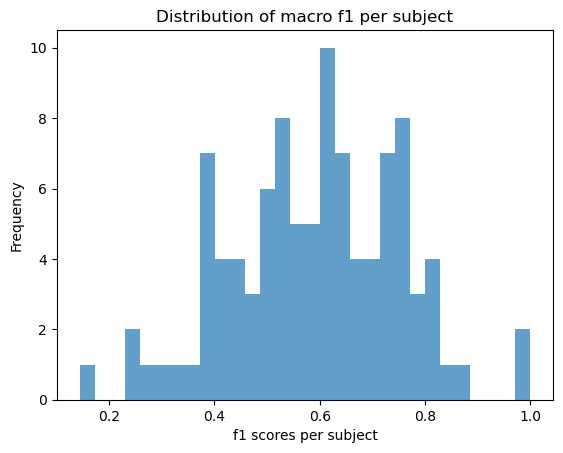

In [40]:
import matplotlib.pyplot as plt

val_df = info_val.copy()
val_df["y_true"] = y_val
val_df["y_pred"] = val_pred
scores = []
for sid, g in val_df.groupby("subject_id"):
    scores.append(f1_score(g.y_true, g.y_pred, average="macro"))
    # print(sid, scores[-1])
plt.hist(scores,bins=30,alpha=0.7)
plt.xlabel('f1 scores per subject')
plt.ylabel('Frequency')
plt.title('Distribution of macro f1 per subject')
plt.show()

## LightGBM

In [17]:
from sklearn.utils.class_weight import compute_sample_weight
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    force_col_wise=True,
    n_jobs=-1,
)
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
lgb.fit(X_train,y_train,sample_weight=sample_weight)

val_pred = lgb.predict(X_val)

print("Val macro F1:", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4,target_names=["W","N1","N2","N3","R"]))

NameError: name 'y_train' is not defined

In [ ]:
imp_gain = pd.Series(
    lgb.booster_.feature_importance(importance_type="gain"),
    index=feat_cols+meta_feature_cols
).sort_values(ascending=False)

print(imp_gain.head(20))

eeg_c4_bp_delta         882957.108513
eeg_cz_bp_high_gamma    187669.683247
eeg_o2_bp_beta          183608.590173
eeg_t3_bp_high_gamma    151771.325898
eeg_cz_bp_delta         147757.593095
eeg_t3_bp_delta         141428.933938
eog_e2_bp_slow          135853.866249
eeg_o2_bp_theta         124241.444281
eeg_fp1_bp_theta         94923.050759
eog_e1_bp_high           94727.438379
eeg_cz_bp_gamma          93796.597848
eeg_cz_bp_beta           83767.741319
emg_chin_bp_high         74892.521844
emg_chin_std             73301.607748
temp_mean                72043.052081
eeg_f4_bp_beta           60817.447384
eeg_o2_bp_high_gamma     59067.513266
eog_e2_bp_delta          59030.307106
eeg_o2_bp_delta          59025.287358
eda_mean                 57340.283037
dtype: float64


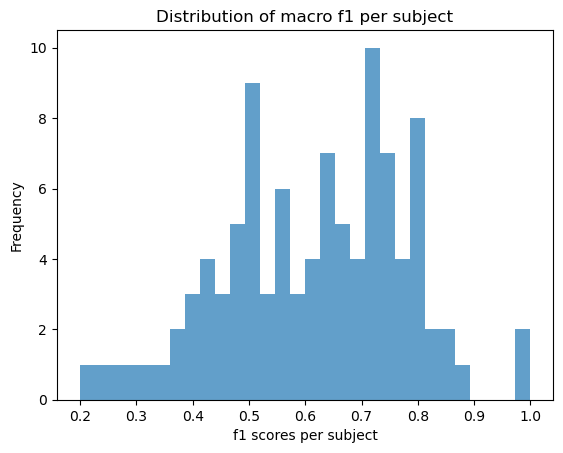

In [ ]:
import matplotlib.pyplot as plt

val_df = info_val.copy()
val_df["y_true"] = y_val
val_df["y_pred"] = val_pred
scores = []
for sid, g in val_df.groupby("subject_id"):
    scores.append(f1_score(g.y_true, g.y_pred, average="macro"))
    # print(sid, scores[-1])
plt.hist(scores,bins=30,alpha=0.7)
plt.xlabel('f1 scores per subject')
plt.ylabel('Frequency')
plt.title('Distribution of macro f1 per subject')
plt.show()

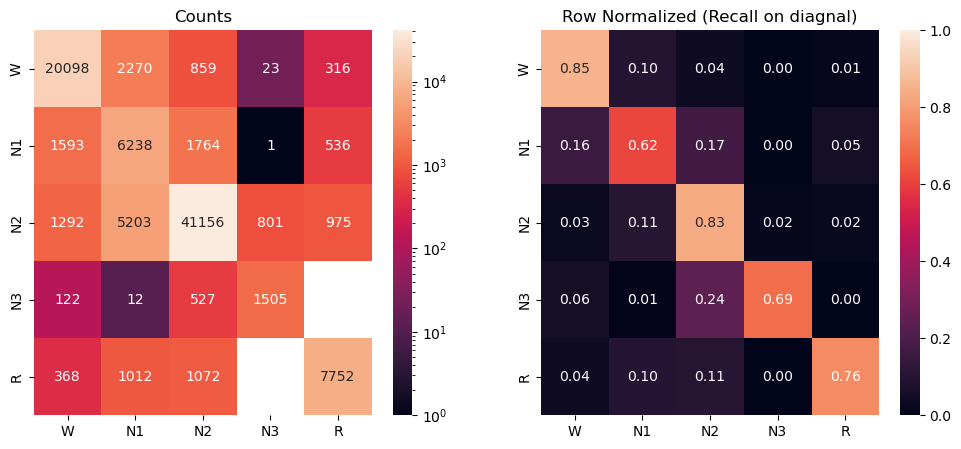

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

labels = list(STAGE_MAP.keys())

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_val, val_pred),
            annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels,
            norm=LogNorm(),
            ax=axes[0])

axes[0].set_title("Counts")

sns.heatmap(confusion_matrix(y_val, val_pred, normalize="true"),
            annot=True, fmt=".2f",
            xticklabels=labels,
            yticklabels=labels,
            vmin=0, vmax=1,
            ax=axes[1])

axes[1].set_title("Row Normalized (Recall on diagnal)")

plt.show()

The reason why N1 recall is low is because it is often mistaken as N2 (the dominant class) and W.

In [ ]:
# try lgb with different parameters
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

param_dist = {
    "num_leaves": [32, 64, 96, 128],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "n_estimators": [400, 800, 1200],
    "min_child_samples": [20, 50, 100, 150],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

lgb = LGBMClassifier(
    objective="multiclass",
    num_class=5
)

lgb_rscv = RandomizedSearchCV(
    lgb,
    param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
)

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
lgb.fit(X_train,y_train,sample_weight=sample_weight)

lgb_rscv.fit(X_train, y_train)
print("Best LightGBM param: \n", lgb_rscv.best_params_)

lgb_best = lgb_rscv.best_estimator_
val_pred = lgb_best.predict(X_val)

print("Val macro F1:", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4,target_names=["W","N1","N2","N3","R"]))

/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49268
[LightGBM] [Info] Number of data points in the train set: 97455, number of used features: 213
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-pack

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.435172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 49235
[LightGBM] [Info] Number of data points in the train set: 64970, number of used features: 213
[LightGBM] [Info] Start training from score -1.400400
[LightGBM] [Info] Start training from score -2.317784
[LightGBM] [Info] Start training from score -0.679147
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.374815 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49235
[LightGBM] [Info] Start training from score -3.064703
[LightGBM] [Info] Start training from score -2.289739
[LightGBM] [Info] Number of data points in the train set: 64970, number of used features: 213[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was

KeyboardInterrupt: 

# Feature Engineering

## add power ratios / lag features

In [39]:
import pandas as pd

def add_core_sleep_ratios_df(X, cols=feat_cols+meta_feature_cols, eps=1e-6):
    df = pd.DataFrame(X, columns=cols)

    eeg_channels = ["eeg_c4", "eeg_f4", "eeg_o2", "eeg_fp1", "eeg_t3", "eeg_cz"]

    for ch in eeg_channels:
        delta = df[f"{ch}_bp_delta"]
        theta = df[f"{ch}_bp_theta"]
        alpha = df[f"{ch}_bp_alpha"]
        sigma = df[f"{ch}_bp_sigma"]
        beta  = df[f"{ch}_bp_beta"]

        total = delta + theta + alpha + sigma + beta

        df[f"{ch}_bp_delta_rel"] = delta / (total + eps)
        df[f"{ch}_bp_theta_rel"] = theta / (total + eps)
        df[f"{ch}_bp_alpha_rel"] = alpha / (total + eps)
        df[f"{ch}_bp_sigma_rel"] = sigma / (total + eps)
        df[f"{ch}_bp_beta_rel"]  = beta  / (total + eps)

        df[f"{ch}_bp_delta_over_theta"] = delta / (theta + eps)
        df[f"{ch}_bp_delta_over_alpha"] = delta / (alpha + eps)
        df[f"{ch}_bp_theta_over_alpha"] = theta / (alpha + eps)
        df[f"{ch}_bp_sigma_over_delta"] = sigma / (delta + eps)

    return df.to_numpy(dtype=np.float32), df.columns.tolist()

In [40]:
X_train_aug, all_cols_aug = add_core_sleep_ratios_df(X_train)
X_val_aug, _ = add_core_sleep_ratios_df(X_val)
X__dev_test_aug, _ = add_core_sleep_ratios_df(X_dev_test)

print("Original:", X_train.shape)
print("Augmented:", X_train_aug.shape)

lgb.fit(X_train_aug, y_train)
val_pred = lgb.predict(X_val_aug)

print("Val macro F1:", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4,target_names=["W","N1","N2","N3","R"]))

Original: (273344, 214)
Augmented: (273344, 268)


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Total Bins 63221
[LightGBM] [Info] Number of data points in the train set: 273344, number of used features: 267
[LightGBM] [Info] Start training from score -1.358813
[LightGBM] [Info] Start training from score -2.217499
[LightGBM] [Info] Start training from score -0.688191
[LightGBM] [Info] Start training from score -3.353771
[LightGBM] [Info] Start training from score -2.335967


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Val macro F1: 0.7270047019302383
              precision    recall  f1-score   support

           W     0.8424    0.8831    0.8622     23566
          N1     0.5121    0.4061    0.4530     10132
          N2     0.8551    0.9165    0.8847     49427
          N3     0.8466    0.5480    0.6654      2166
           R     0.8535    0.7009    0.7697     10204

    accuracy                         0.8227     95495
   macro avg     0.7819    0.6909    0.7270     95495
weighted avg     0.8152    0.8227    0.8161     95495



In [41]:
import numpy as np
import pandas as pd


def add_lag_features(X, feature_names, lag_features, lags=(1, 2, 3)):
    """
    Add lag features to selected columns.
    """
    df = pd.DataFrame(X, columns=feature_names)

    for col in lag_features:
        if col not in df.columns:
            raise ValueError(f"{col} not found in feature_names")
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    keep_idx = np.arange(max(lags), len(df))
    df = df.iloc[keep_idx].reset_index(drop=True)

    feature_names_new = df.columns.tolist()
    X_new = df.to_numpy(dtype=np.float32)

    return X_new, feature_names_new, keep_idx

In [42]:
lag_features = [
    "eeg_c4_bp_delta",
    "eeg_o2_bp_theta",
    "eog_e2_bp_slow",
    "eeg_cz_bp_delta",
    "eeg_cz_bp_high_gamma",
    "hr_mean",
    "temp_mean",
]

X_train_aug, feature_names_aug, keep_idx = add_lag_features(
    X_train,
    feature_names=feat_cols+meta_feature_cols,
    lag_features=lag_features,
    lags=(1, 2),
)
y_train_aug = y_train[keep_idx]
info_train_aug = info_train.iloc[keep_idx].reset_index(drop=True)

X_val_aug, _, keep_idx = add_lag_features(
    X_val,
    feature_names=feat_cols+meta_feature_cols,
    lag_features=lag_features,
    lags=(1, 2),
)
y_val_aug = y_val[keep_idx]
info_val_aug = info_val.iloc[keep_idx].reset_index(drop=True)

X_dev_test_aug, _, keep_idx = add_lag_features(
    X_dev_test,
    feature_names=feat_cols+meta_feature_cols,
    lag_features=lag_features,
    lags=(1, 2),
)
y_dev_test_aug = y_dev_test[keep_idx]
info_dev_test_aug = info_dev_test.iloc[keep_idx].reset_index(drop=True)

lgb.fit(X_train_aug, y_train_aug)
val_pred = lgb.predict(X_val_aug)

print("Val macro F1:", f1_score(y_val_aug, val_pred, average="macro"))
print(classification_report(y_val_aug, val_pred, digits=4,target_names=["W","N1","N2","N3","R"]))


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Total Bins 53021
[LightGBM] [Info] Number of data points in the train set: 273342, number of used features: 227
[LightGBM] [Info] Start training from score -1.358820
[LightGBM] [Info] Start training from score -2.217491
[LightGBM] [Info] Start training from score -0.688184
[LightGBM] [Info] Start training from score -3.353764
[LightGBM] [Info] Start training from score -2.335997


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Val macro F1: 0.7264707119664724
              precision    recall  f1-score   support

           W     0.8428    0.8857    0.8637     23564
          N1     0.5128    0.4127    0.4573     10132
          N2     0.8576    0.9143    0.8851     49427
          N3     0.8394    0.5355    0.6539      2166
           R     0.8499    0.7078    0.7724     10204

    accuracy                         0.8234     95493
   macro avg     0.7805    0.6912    0.7265     95493
weighted avg     0.8161    0.8234    0.8171     95493



## post process: smoothing
use median filter for 5 epoch kernel to count for smooth transition

In [ ]:
from scipy.signal import medfilt
lgb.fit(X_train,y_train,sample_weight=sample_weight)

val_pred = lgb.predict(X_val)
val_pred_smooth = medfilt(val_pred, kernel_size=5)
print("Val macro F1:", f1_score(y_val, val_pred_smooth, average="macro"))
print(classification_report(y_val, val_pred_smooth, digits=4,target_names=["W","N1","N2","N3","R"]))

/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Total Bins 49451
[LightGBM] [Info] Number of data points in the train set: 273344, number of used features: 213
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/Users/adiacheng1/miniconda3/envs/Sleep_Staging/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Val macro F1: 0.7458242686662664
              precision    recall  f1-score   support

           W     0.8694    0.8539    0.8615     23566
          N1     0.4310    0.6325    0.5127     10132
          N2     0.9077    0.8405    0.8728     49427
          N3     0.6750    0.6981    0.6863      2166
           R     0.8265    0.7673    0.7958     10204

    accuracy                         0.8107     95495
   macro avg     0.7419    0.7584    0.7458     95495
weighted avg     0.8337    0.8107    0.8193     95495



# NN Models

## MLP

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report

mlp = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42,
    ))
])

mlp.fit(X_train, y_train)
val_pred = mlp.predict(X_val)

print("Val macro F1:", f1_score(y_val, val_pred, average="macro"))
print(classification_report(y_val, val_pred, digits=4))

Val macro F1: 0.6330860139052611
              precision    recall  f1-score   support

           0     0.7467    0.8189    0.7812     23566
           1     0.3587    0.3197    0.3381     10132
           2     0.8255    0.8479    0.8365     49427
           3     0.6492    0.5605    0.6016      2166
           4     0.6925    0.5419    0.6081     10204

    accuracy                         0.7455     95495
   macro avg     0.6545    0.6178    0.6331     95495
weighted avg     0.7383    0.7455    0.7402     95495



## LSTM

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset


class SleepSequenceDataset(Dataset):
    """
    Many-to-one sequence dataset for sleep staging.

    Assumes:
    - X and y are flattened epoch-level arrays
    - info is block-level metadata stored in self.all_blocks
    - each row in self.all_blocks corresponds to one contiguous block
    - n_rows_final gives the number of valid rows in that block

    For each valid endpoint t inside a block:
        input  = X[t-seq_len+1 : t+1]
        target = y[t]
    """
    def __init__(
        self,
        X,
        y,
        info,
        seq_len=int(30*60//5)-5,
        n_rows_col="n_rows_final",
    ):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.seq_len = seq_len

        if isinstance(info, pd.DataFrame):
            self.all_blocks = info.reset_index(drop=True).copy()
        else:
            self.all_blocks = pd.DataFrame(info).reset_index(drop=True)

        if n_rows_col not in self.all_blocks.columns:
            raise ValueError(f"Missing required info column: {n_rows_col}")

        self.n_rows_col = n_rows_col
        self.samples = []

        start = 0
        for _, row in self.all_blocks.iterrows():
            block_len = int(row[n_rows_col])
            end = start + block_len

            if block_len >= seq_len:
                for end_pos in range(start + seq_len - 1, end):
                    seq_idx = np.arange(end_pos - seq_len + 1, end_pos + 1)
                    target_idx = end_pos
                    self.samples.append((seq_idx, target_idx))

            start = end

        if start != len(self.X):
            raise ValueError(
                f"Total rows from info ({start}) does not match len(X) ({len(self.X)})"
            )

        if len(self.X) != len(self.y):
            raise ValueError(f"len(X)={len(self.X)} != len(y)={len(self.y)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        seq_idx, target_idx = self.samples[i]
        x_seq = torch.from_numpy(self.X[seq_idx])   # (seq_len, n_features)
        y_target = torch.tensor(self.y[target_idx], dtype=torch.long)
        return x_seq, y_target